In [26]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [27]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

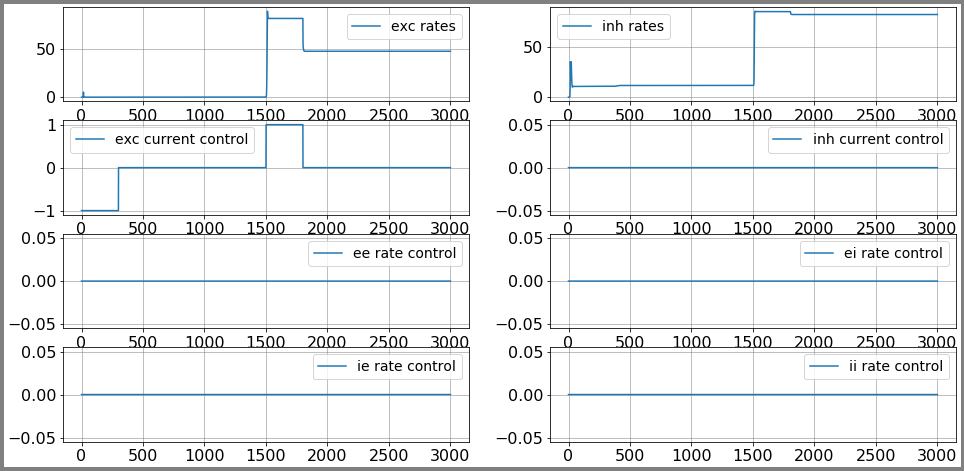

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


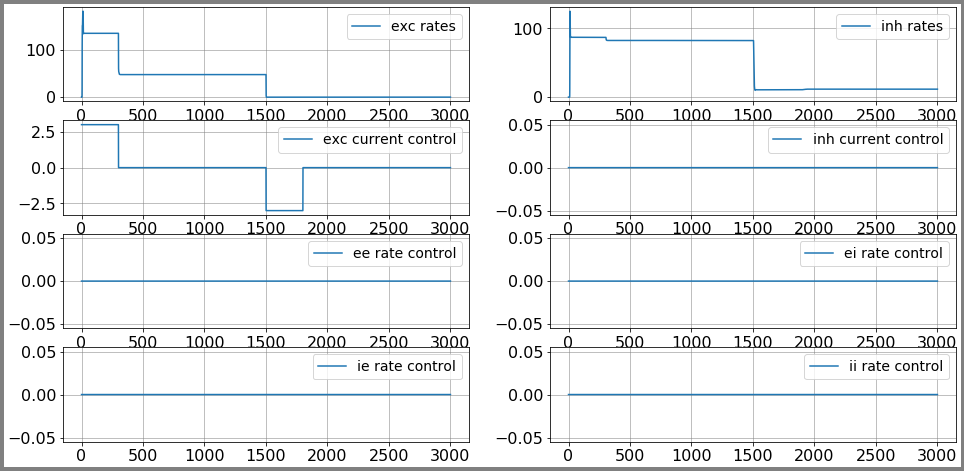

In [28]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]


In [29]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1], [2], [3], [4], [5], [2,3,4,5] ]
p_var = [ [0], [0], [0], [0], [0], [0], [0], [0] ]

bestControla = [ [], [], [], [], [], [], [], [] ]
bestStatea = [ [], [], [], [], [], [], [], [] ]
costa = [ [], [], [], [], [], [], [], [] ]
runtimea = [ [], [], [], [], [], [], [], [] ]
grada = [ [], [], [], [], [], [], [], [] ]
phia= [ [], [], [], [], [], [], [], [] ]

bestControlb = [ [], [], [], [], [], [], [], [] ]
bestStateb = [ [], [], [], [], [], [], [], [] ]
costb = [ [], [], [], [], [], [], [], [] ]
runtimeb = [ [], [], [], [], [], [], [], [] ]
gradb = [ [], [], [], [], [], [], [], [] ]
phib= [ [], [], [], [], [], [], [], [] ]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])
initVars = low_state_vars

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

sheet = "state_switching"
max_it = 1000

### Cases

Numer | Input | Input label | Result
---------|--------------|-----------|-----------
1 | E current | 0 | 0
2 | I current | 1 | 0
3 | E + I current | 0,1 | 0
4 | EE rate | 2 | 0
5 | EI rate | 3 | 0
6 | IE rate | 4 | 0
7 | II rate | 5 | 0
8 | EE + EI + IE + II rate | 2,3,4,5 | 0

## 1

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1778.9203660693015
RUN  3 , total integrated cost =  89.15108951247882
RUN  4 , total integrated cost =  21.38238446628905
RUN  5 , total integrated cost =  9.302117816895592
RUN  6 , total integrated cost =  5.400643216093798
RUN  7 , total integrated cost =  3.6216180163576244
RUN  8 , total integrated cost =  2.5974319033783986
RUN  9 , total integrated cost =  1.9441276854019511
RUN  10 , total integrated cost =  1.5263339942531167
RUN  11 , total integrated cost =  1.2425486610332994
RUN  12 , total integrated cost =  1.0310405867183763
RUN  13 , total integrated cost =  0.8636988660672524
RUN  14 , total integrated cost =  0.735332655717568
RUN  15 , total integrated cost =  0.639349041016721
RUN  16 , total integr

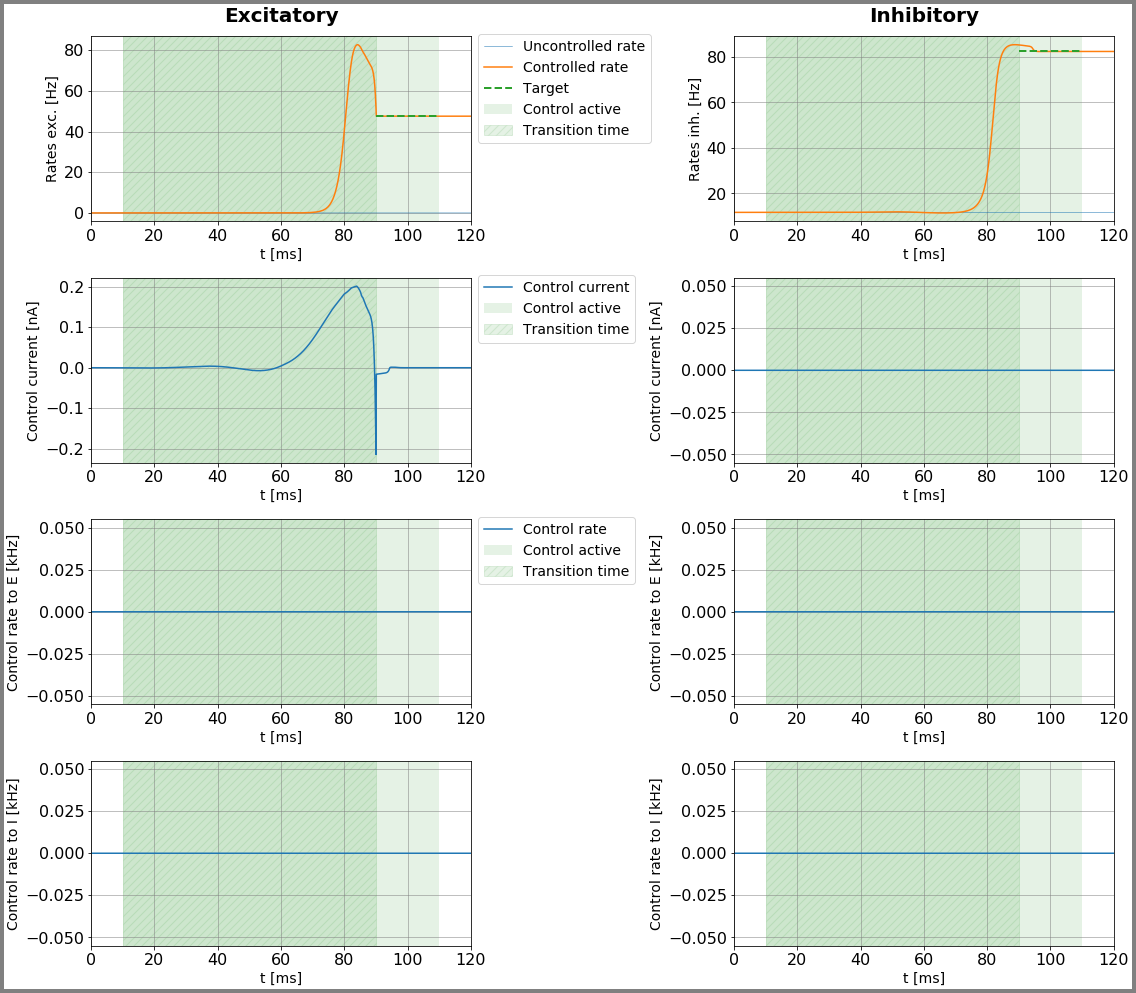

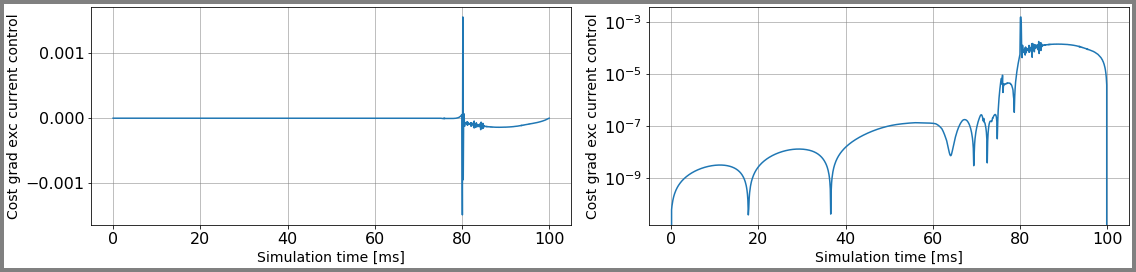

In [30]:
c_ = 0
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(control0,
    target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [31]:
c_ = 0
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = "PR"
max_it = 20

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params


TypeError: list indices must be integers or slices, not tuple

## 2

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  3859.672296503376
RUN  2 , total integrated cost =  88.30540409162167
RUN  3 , total integrated cost =  1.2412311560575862
RUN  4 , total integrated cost =  0.0598230614877892
RUN  5 , total integrated cost =  0.029961637979352862
RUN  6 , total integrated cost =  0.002949038737146899
RUN  7 , total integrated cost =  0.0015037102635284587
RUN  8 , total integrated cost =  0.0011131193937577847
RUN  9 , total integrated cost =  0.0008873623634675265
RUN  10 , total integrated cost =  0.0007342924806327018
RUN  11 , total integrated cost =  0.0006198705246234058
RUN  12 , total integrated cost =  0.000528319977673254
RUN  13 , total integrated cost =  0.00045085164027131844
RUN  14 , total integrated cost =  0.00038826517153170214
RUN  15 , total integrated cost =  0.00033

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  8.326046583743515e-08
RUN  1000 , total integrated cost =  8.326046583743515e-08
Improved over  1000  iterations in  24.210098799999997  seconds by  99.99999999962985  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459399763963 -56.174597782292906


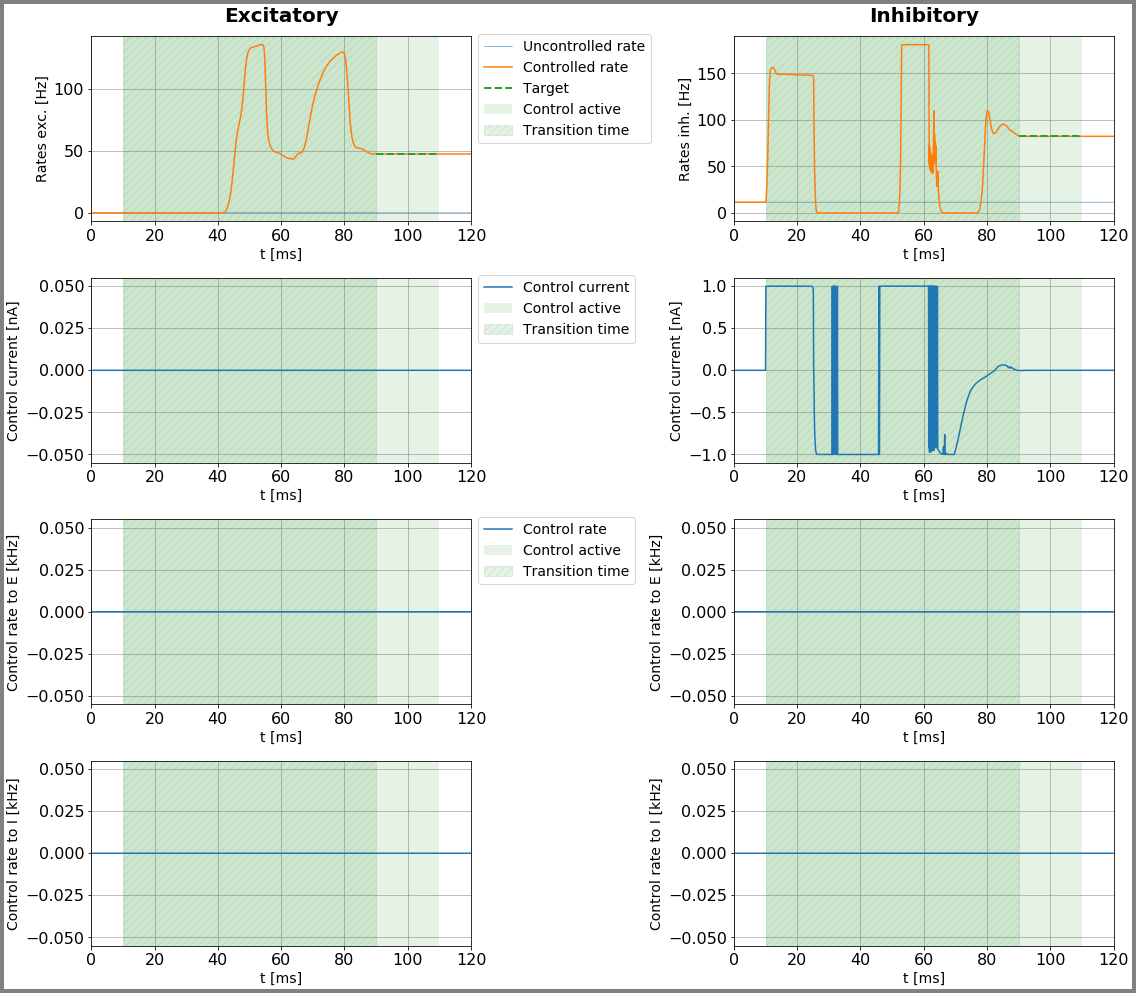

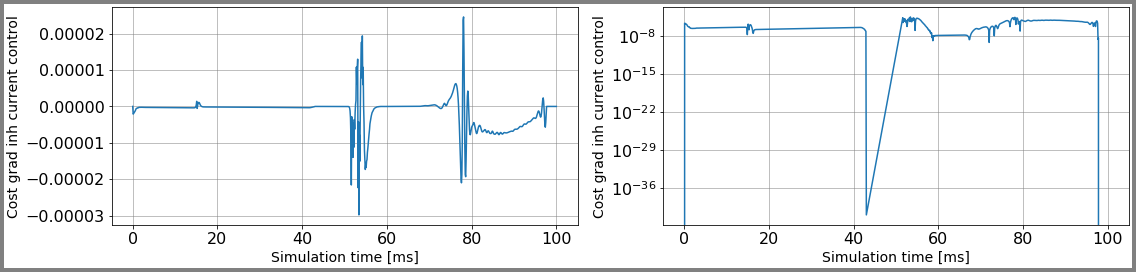

In [7]:
c_ = 1
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  80178.15527629462
Gradient descend method:  None
RUN  1 , total integrated cost =  368.9775719681506
RUN  2 , total integrated cost =  174.15836006476118
RUN  3 , total integrated cost =  140.1244105938733
RUN  4 , total integrated cost =  139.7942258582168
RUN  5 , total integrated cost =  136.6791393539059
RUN  6 , total integrated cost =  95.89241420936607
RUN  7 , total integrated cost =  94.08854780701965
RUN  8 , total integrated cost =  94.03425881785557
RUN  9 , total integrated cost =  93.93516036993815
RUN  10 , total integrated cost =  93.89583345435706
RUN  11 , total integrated cost =  93.80417027856821
RUN  12 , total integrated cost =  93.76605327233067
RUN  13 , total integrated cost =  93.68647971754645
RUN  14 , total integrated cost =  93.65295251767898
RUN  15 , total integrated cost =  93.58109090922791
RUN  16 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  49.91878128543388
RUN  1000 , total integrated cost =  49.91878128543388
Improved over  1000  iterations in  28.097014599999994  seconds by  99.93774017235316  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459044255673 -56.174590472455236


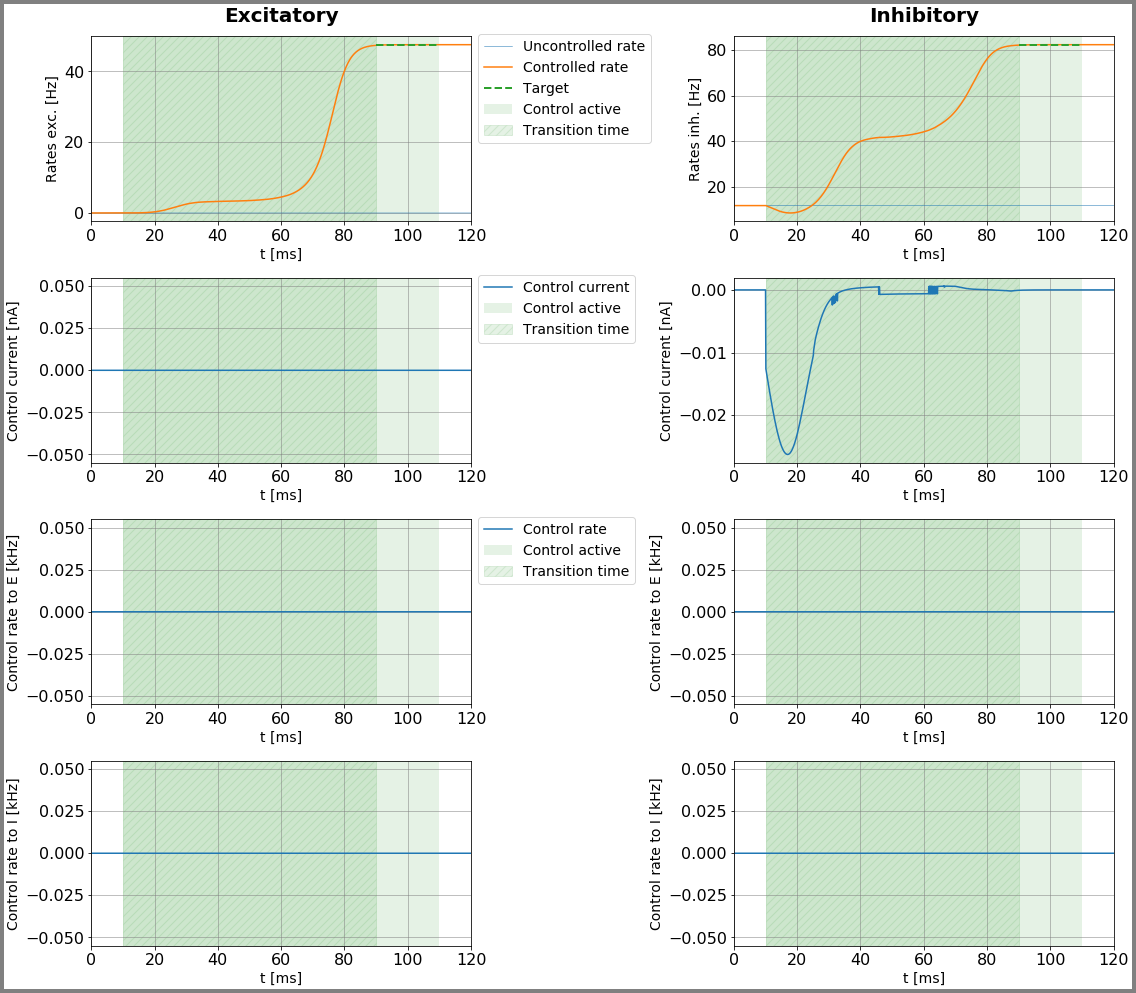

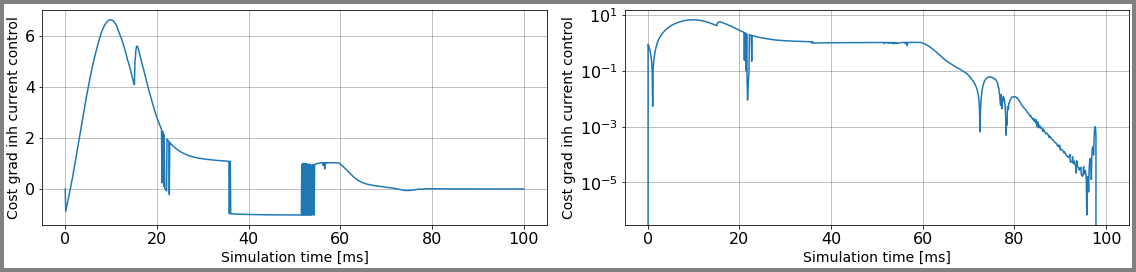

In [8]:
c_ = 1
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 3

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1727.5249571588436
RUN  3 , total integrated cost =  537.9247471416692
RUN  4 , total integrated cost =  310.94839325314246
RUN  5 , total integrated cost =  199.0846206850091
RUN  6 , total integrated cost =  132.08026047641465
RUN  7 , total integrated cost =  89.81125768788664
RUN  8 , total integrated cost =  64.6722086266404
RUN  9 , total integrated cost =  47.648911482440894
RUN  10 , total integrated cost =  36.7603536670014
RUN  11 , total integrated cost =  29.258933102448715
RUN  12 , total integrated cost =  23.906448836445445
RUN  13 , total integrated cost =  20.032118726877286
RUN  14 , total integrated cost =  17.095538808581622
RUN  15 , total integrated cost =  14.780863171054927
RUN  16 , total inte

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.00046238711798886074
RUN  1000 , total integrated cost =  0.00046238711798886074
Improved over  1000  iterations in  46.92715469999999  seconds by  99.99999794435178  percent.
Problem in initial value trasfer:  Vmean_exc -56.174590026845394 -56.174585427317744


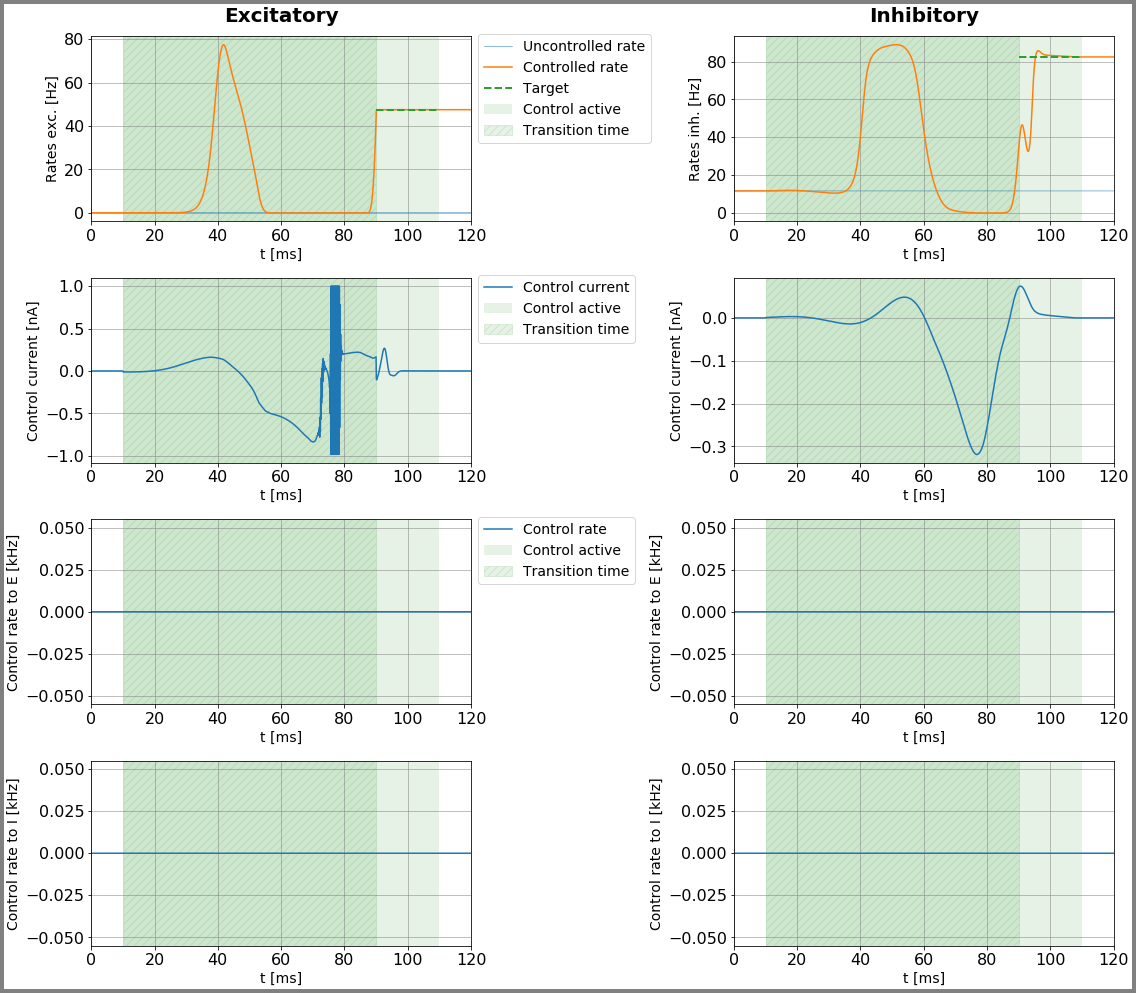

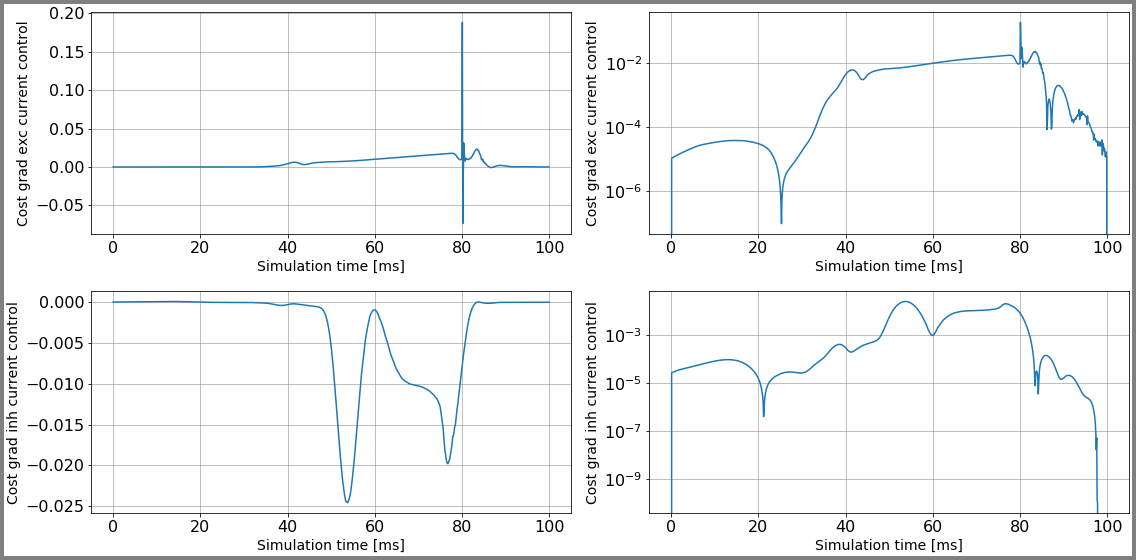

In [9]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18328.204554534866
Gradient descend method:  None
RUN  1 , total integrated cost =  1773.4001372357666
RUN  2 , total integrated cost =  164.66429637358533
RUN  3 , total integrated cost =  138.95511046677933
RUN  4 , total integrated cost =  131.00461861672602
RUN  5 , total integrated cost =  127.2948774775995
RUN  6 , total integrated cost =  124.93286271237295
RUN  7 , total integrated cost =  122.18077117644214
RUN  8 , total integrated cost =  120.27162948694189
RUN  9 , total integrated cost =  117.96510972418496
RUN  10 , total integrated cost =  116.22059426706801
RUN  11 , total integrated cost =  114.1200219462789
RUN  12 , total integrated cost =  112.53413243500728
RUN  13 , total integrated cost =  110.60381640856716
RUN  14 , total integrated cost =  109.16079913264373
RUN  15 , total integrated cost =  107.37560964517426
RUN  16 , tota

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  50.10128848105211
RUN  1000 , total integrated cost =  50.10128848105211
Improved over  1000  iterations in  78.70471490000003  seconds by  99.72664377281485  percent.
Problem in initial value trasfer:  Vmean_exc -56.174588306788344 -56.174588421309835


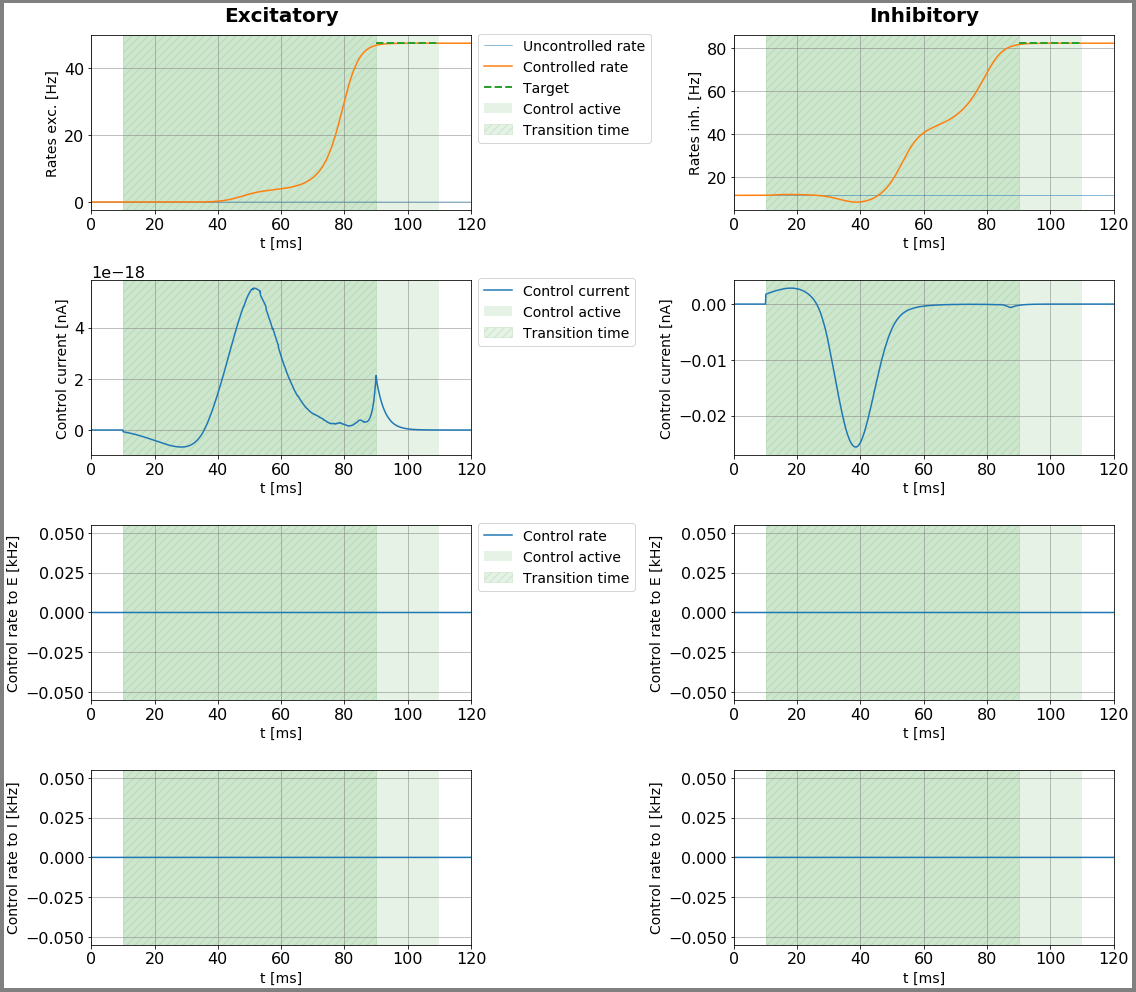

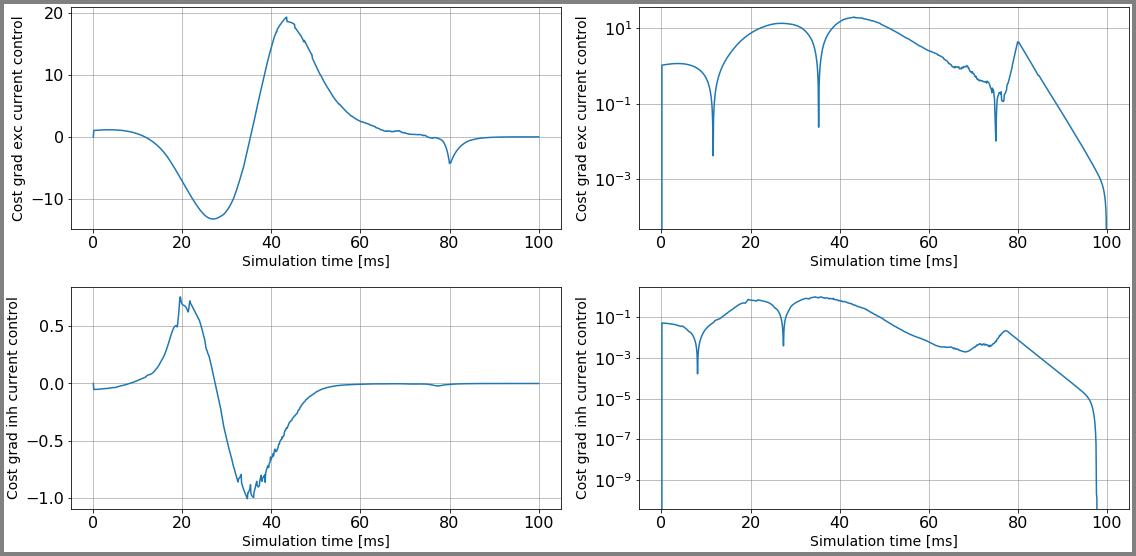

In [10]:
c_ = 2
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 4

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  66.118537293759
Gradient descend method:  None
RUN  1 , total integrated cost =  0.0041328846651302225
RUN  2 , total integrated cost =  3.3860742682112444e-06
RUN  3 , total integrated cost =  2.3209295352026843e-09
RUN  4 , total integrated cost =  1.7162118811671267e-12
RUN  5 , total integrated cost =  8.446330420761881e-15
RUN  6 , total integrated cost =  4.523163208947072e-18
RUN  7 , total integrated cost =  5.730054925586144e-20
RUN  8 , total integrated cost =  1.7096950844418773e-24
RUN  9 , total integrated cost =  1.3342730242035641e-25
RUN  10 , total integrated cost =  8.423014983843043e-26
RUN  11 , total integrated cost =  6.959898885711531e-26
RUN  12 , total integrated cost =  6.897294884273186e-26
RUN  13 , total integrated cost =  6.888207206645042e-26
RUN  14 , total integrated cost =  6.87432325471315e-26
RUN  15 , total integrated

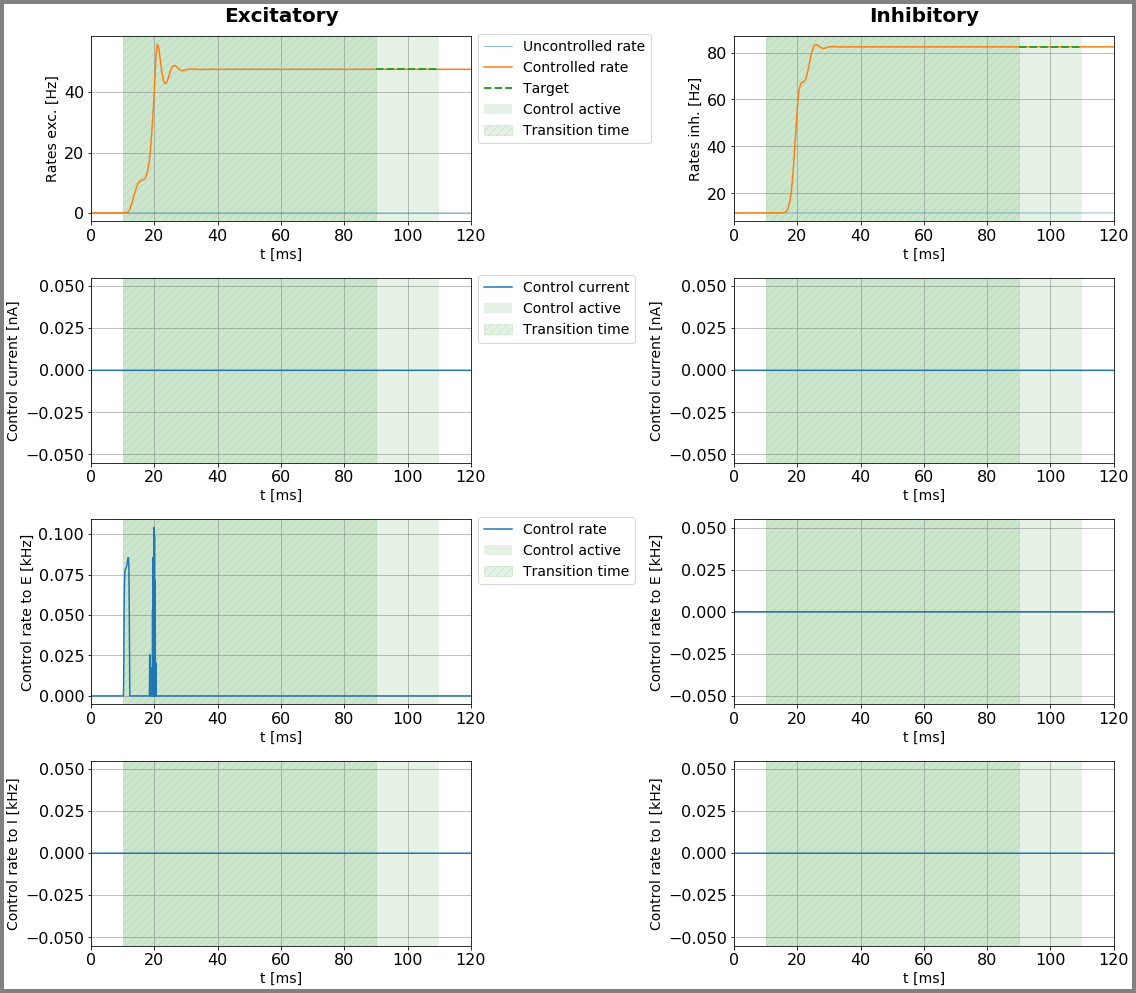

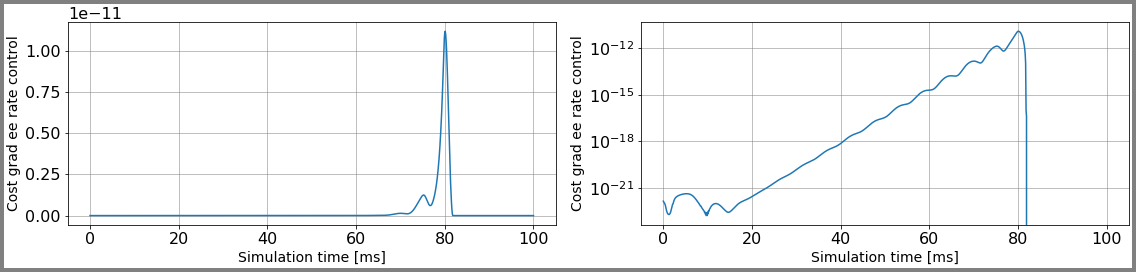

In [11]:
c_ = 3
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12.566217885613183
Gradient descend method:  None
RUN  1 , total integrated cost =  1.6344252122504965
RUN  2 , total integrated cost =  1.6024758903435954
RUN  3 , total integrated cost =  0.7424633206677977
RUN  4 , total integrated cost =  0.7008991652411553
RUN  5 , total integrated cost =  0.6995337030541419
RUN  6 , total integrated cost =  0.621102735425718
RUN  7 , total integrated cost =  0.6152712164486432
RUN  8 , total integrated cost =  0.6152255244944573
RUN  9 , total integrated cost =  0.6151869635768552
RUN  10 , total integrated cost =  0.6151535820760028
RUN  11 , total integrated cost =  0.6129794951041048
RUN  12 , total integrated cost =  0.6124998501365504
RUN  13 , total integrated cost =  0.6124978449442648
RUN  14 , total integrated cost =  0.6124956524852405
RUN  15 , total integrated cost =  0.6124937707715118
RUN  16 , total 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.6099459395876484
RUN  1000 , total integrated cost =  0.6099459395876484
Improved over  1000  iterations in  24.631365500000015  seconds by  95.14614544217028  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144023103226604
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.108050466826644


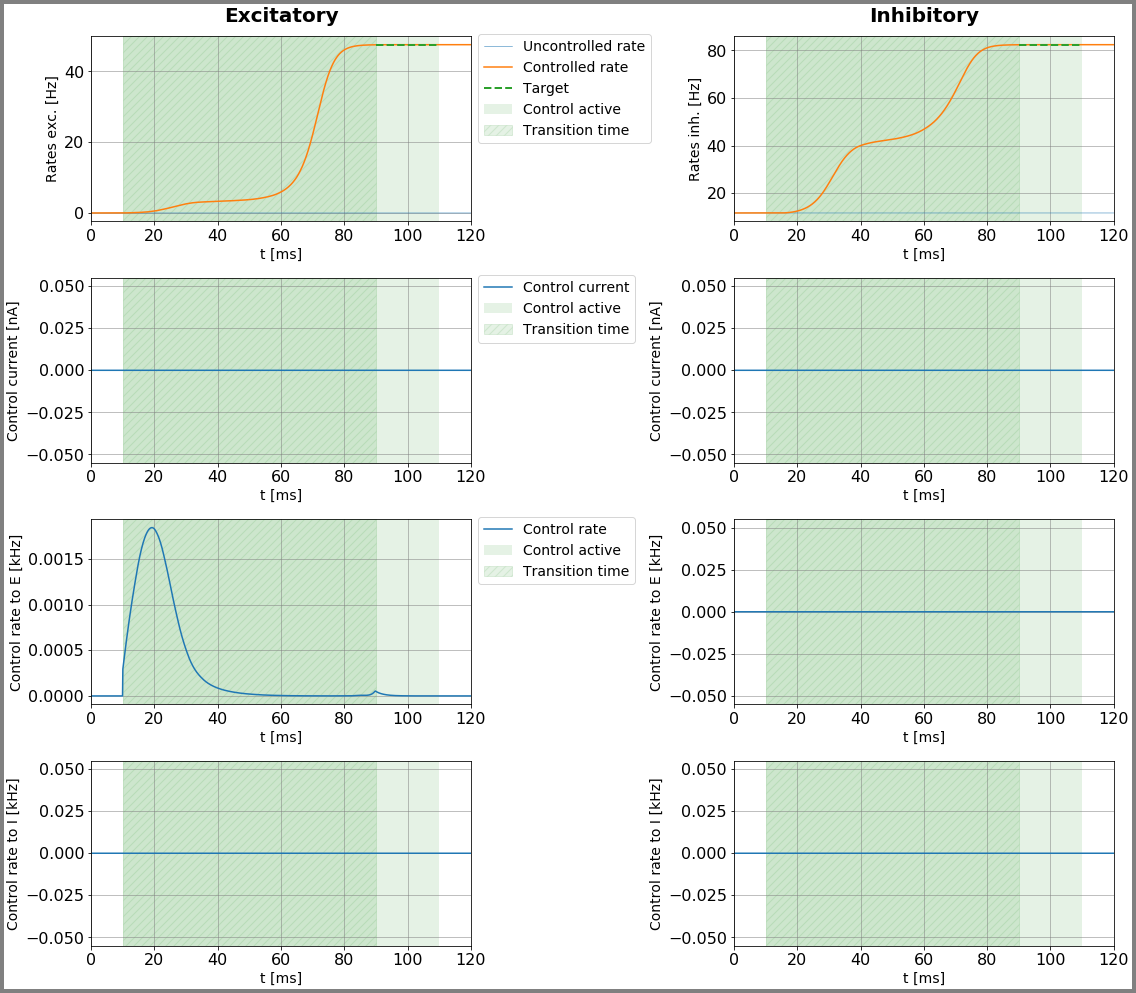

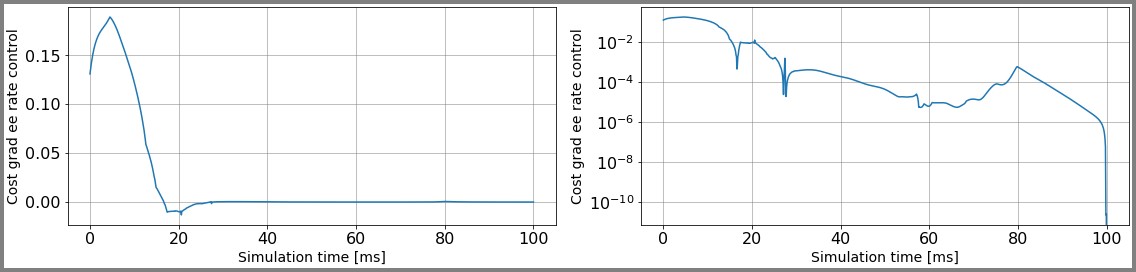

In [12]:
c_ = 3
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 5

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.018028999999955886  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 0.5040524962491215 0.5154316538394573
Problem in initial value trasfer:  Vmean_exc -74.67928608822606 -74.68007589103325
Problem in initial value trasfer:  tau_exc 26.846481425593925 26.785113928669478


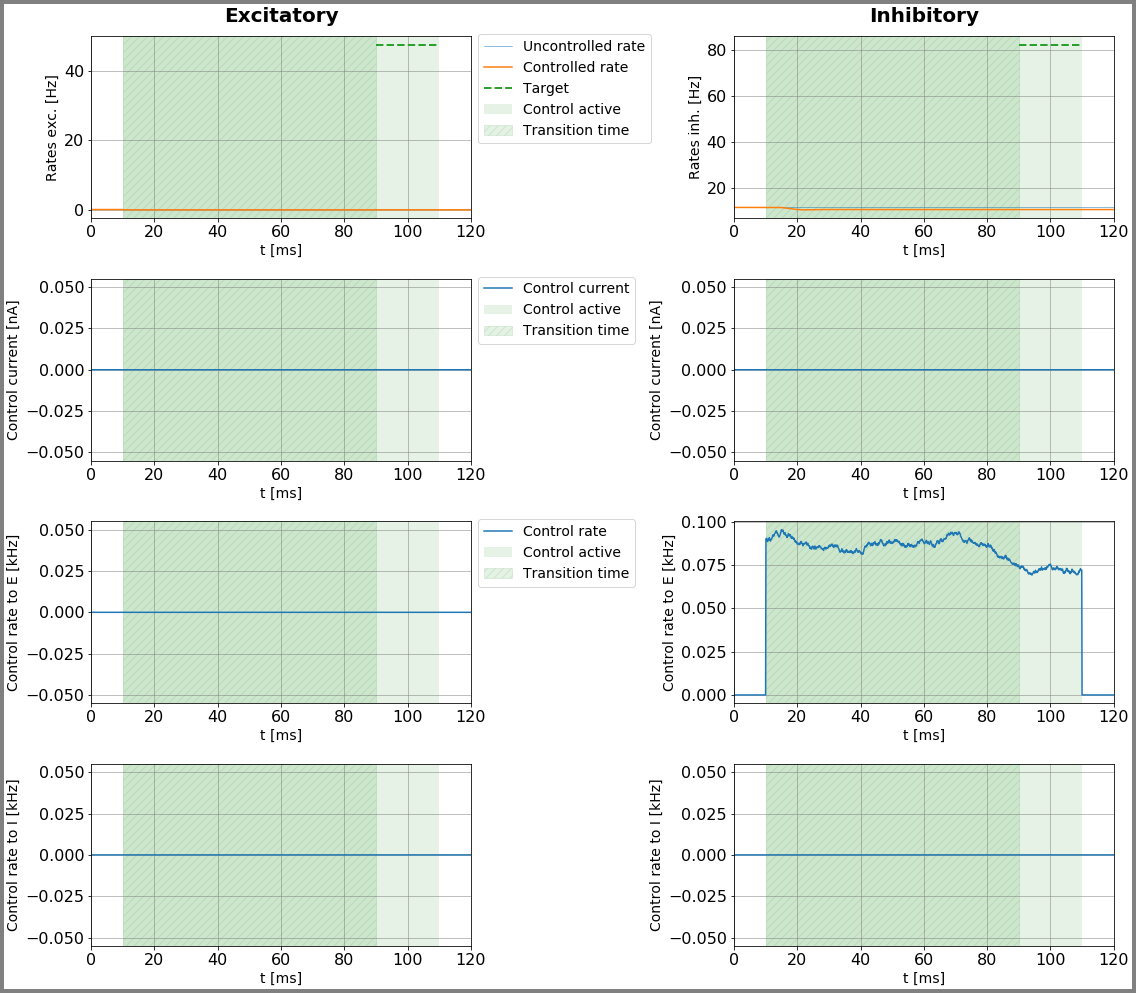

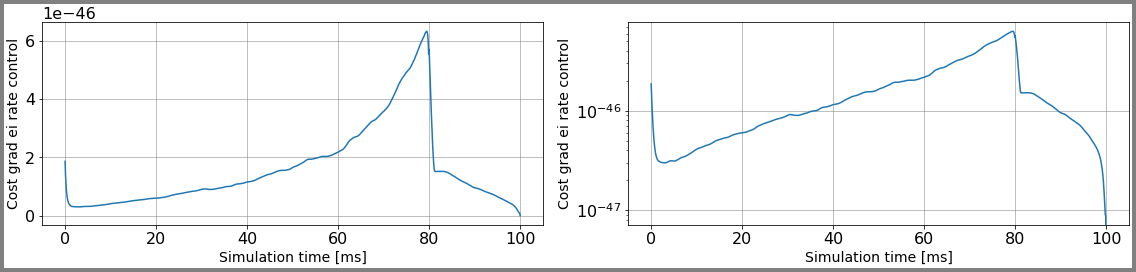

In [13]:
c_ = 4
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22691.19066375784
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
RUN  2 , total integrated cost =  22493.34777445878
RUN  3 , total integrated cost =  22492.302010986437
RUN  4 , total integrated cost =  22492.291594605787
RUN  5 , total integrated cost =  22492.291266410546
RUN  6 , total integrated cost =  

ERROR:root:Problem in initial value trasfer


22492.291263363306
RUN  7 , total integrated cost =  22492.291263363302
RUN  8 , total integrated cost =  22492.291263363302
Control only changes marginally.
RUN  8 , total integrated cost =  22492.291263363302
Improved over  8  iterations in  0.30404329999998936  seconds by  0.8765489803592317  percent.
Problem in initial value trasfer:  Vmean_exc -56.29876665805448 -56.298893356885614


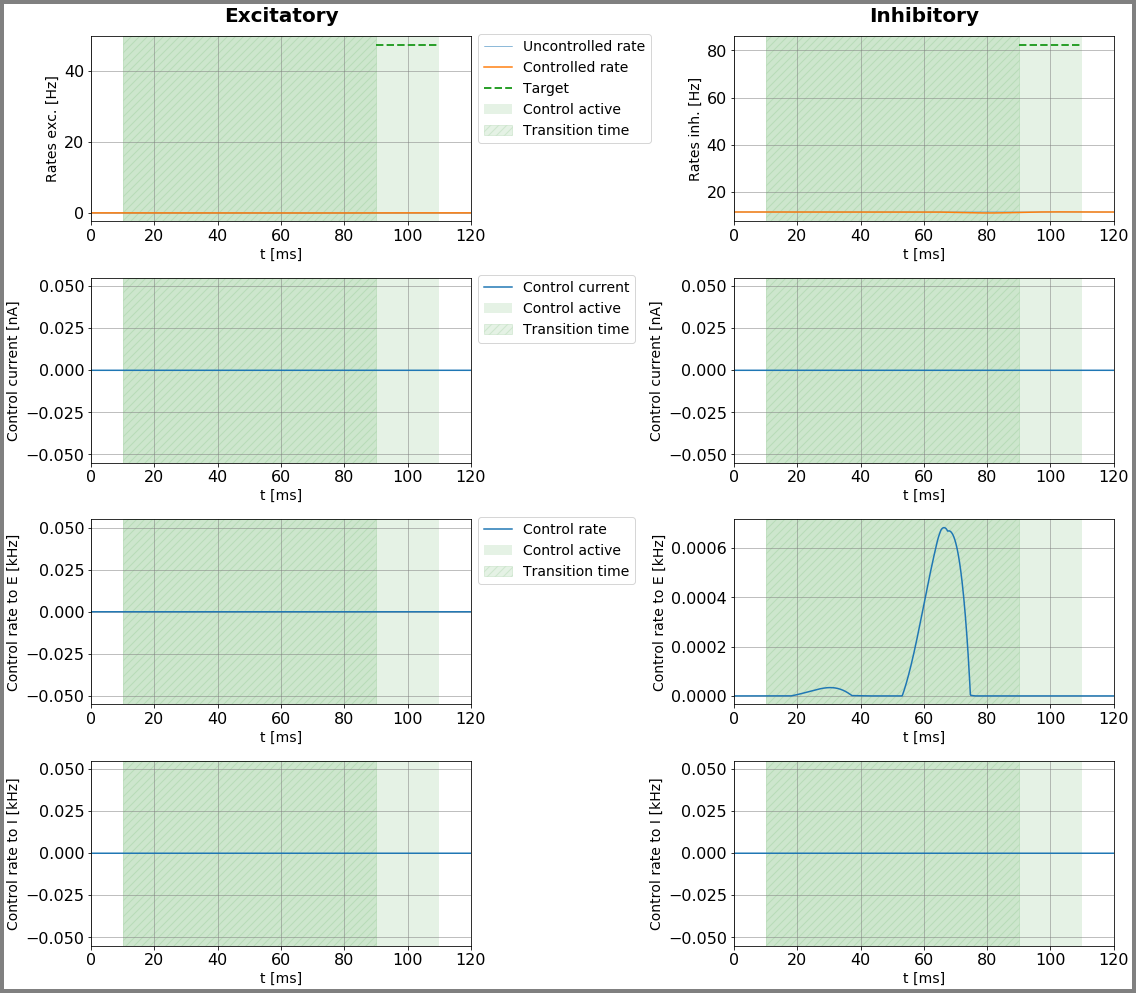

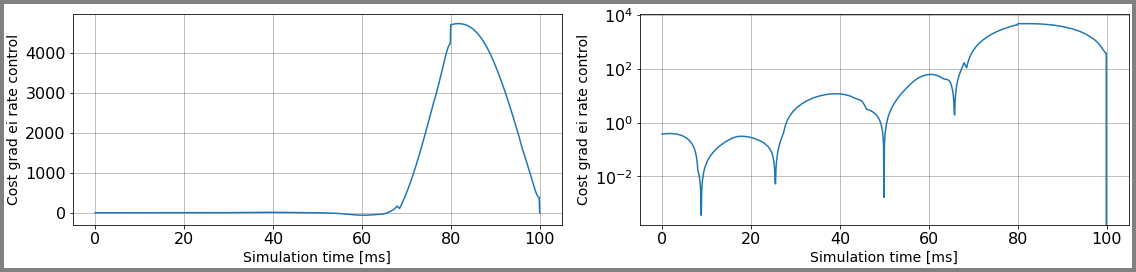

In [14]:
c_ = 4
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 6

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.019143999999982952  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5115655722003538 0.5483164692444142
Problem in initial value trasfer:  Vmean_exc -75.04762971152651 -75.04979771359123


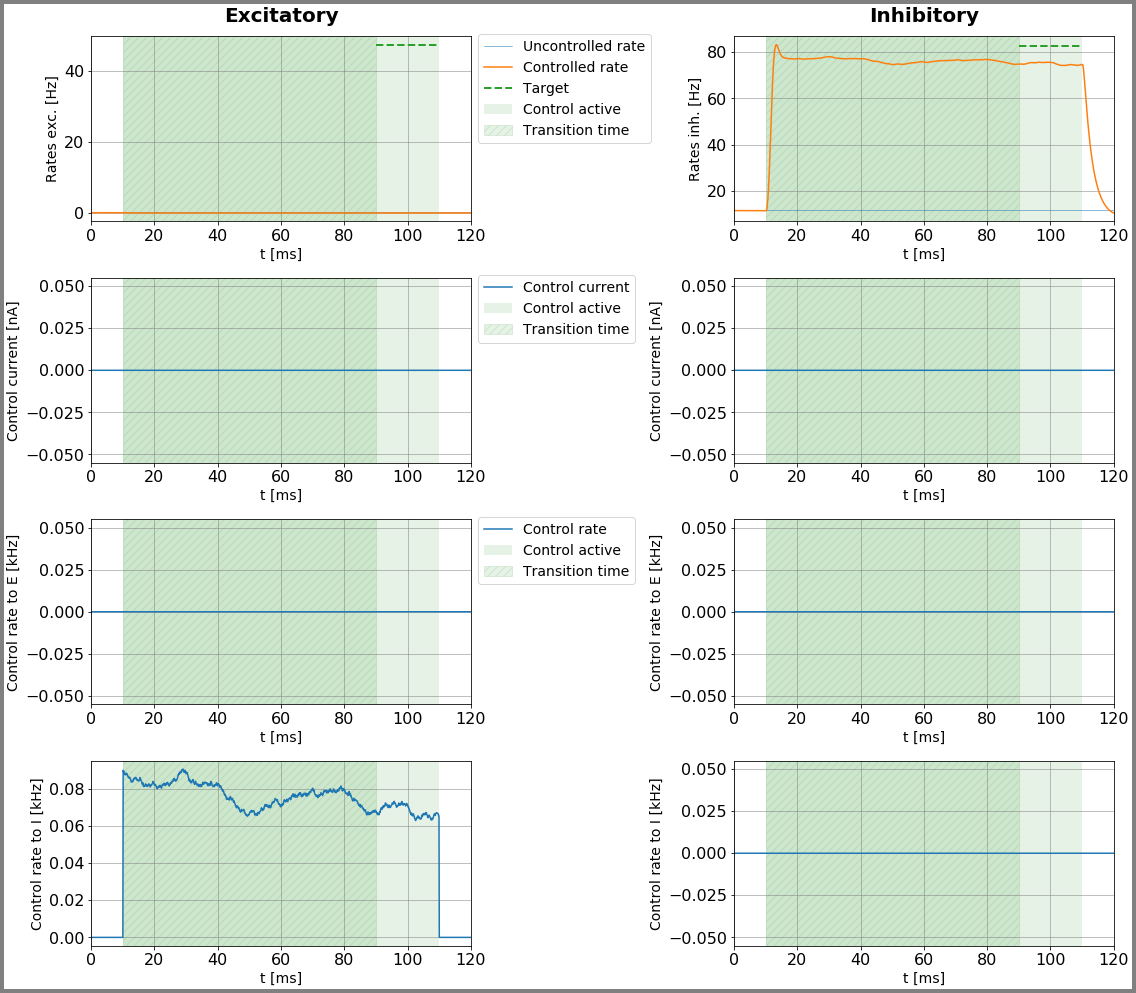

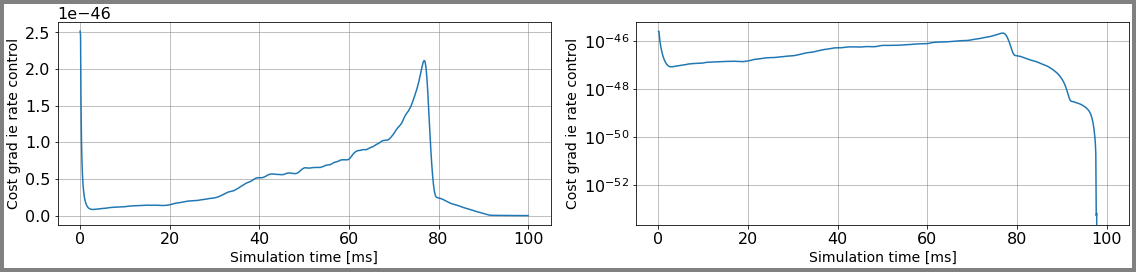

In [15]:
c_ = 5
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22676.606188317655
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
RUN  2 , total integrated cost =  22493.205225769263
RUN  3 , total integrated cost =  22492.184065981408
RUN  4 , total integrated cost =  22492.177371560465
RUN  5 , total integrated cost =  22492.17672661437


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  22492.176719237006
RUN  7 , total integrated cost =  22492.176719139563
RUN  8 , total integrated cost =  22492.176719139563
Control only changes marginally.
RUN  8 , total integrated cost =  22492.176719139563
Improved over  8  iterations in  0.28870169999999007  seconds by  0.8133027828172317  percent.
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.382311323526517
Problem in initial value trasfer:  Vmean_exc -56.29824218663594 -56.298369490351355


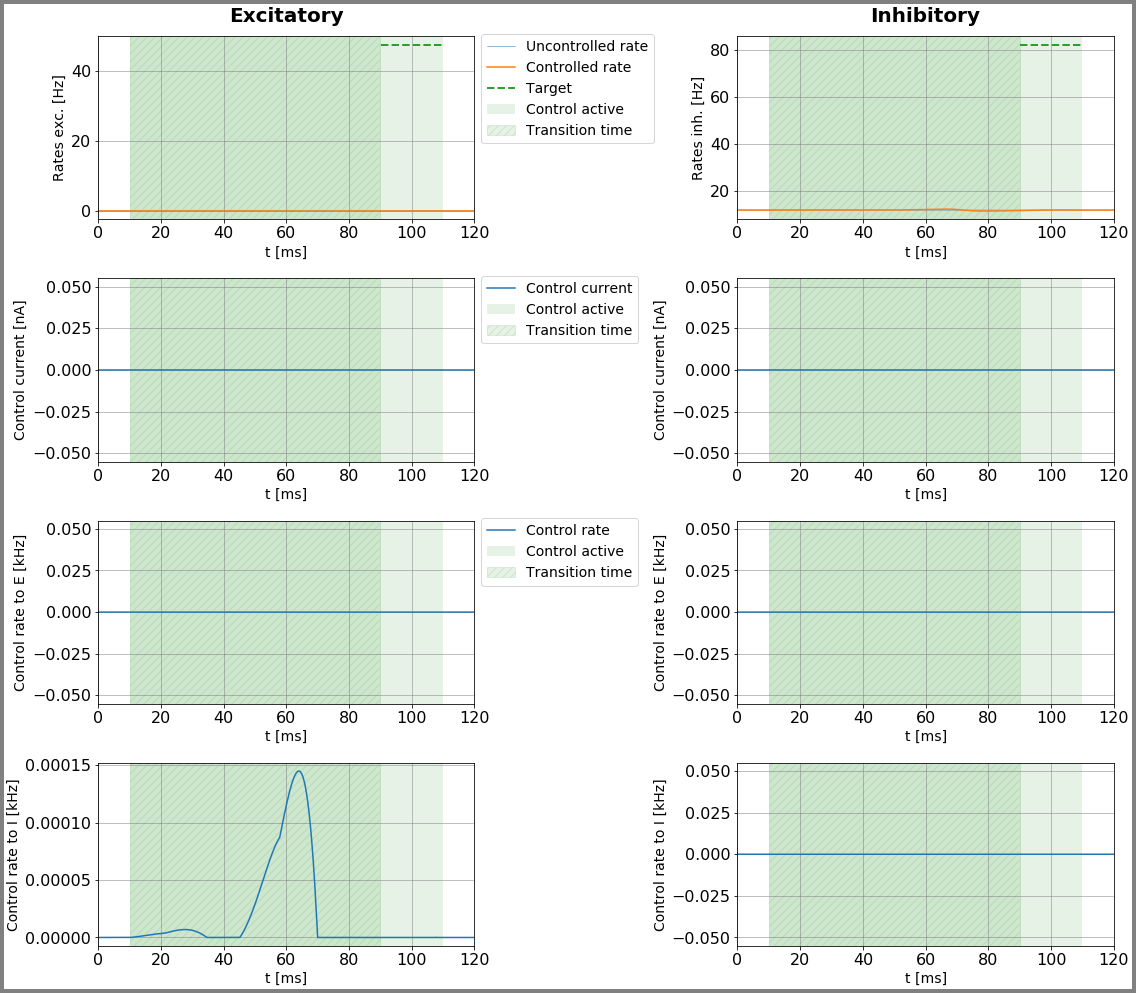

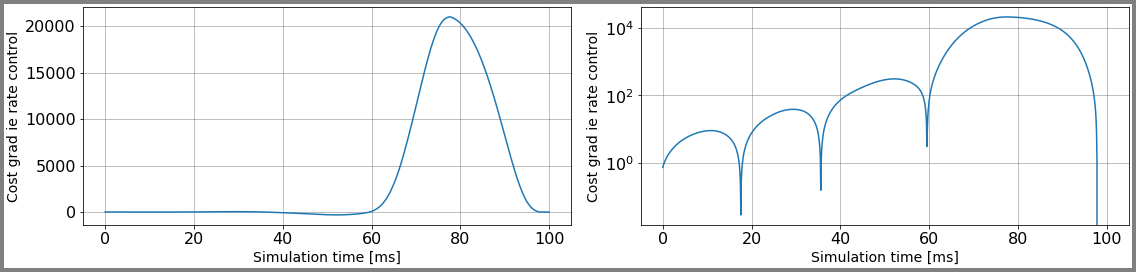

In [16]:
c_ = 5
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 7

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.08185137777406201
Gradient descend method:  None
RUN  1 , total integrated cost =  3.728151704328847e-13
RUN  2 , total integrated cost =  3.117637231736708e-13
RUN  3 , total integrated cost =  2.1408910849297413e-13
RUN  4 , total integrated cost =  1.1464085737628228e-13
RUN  5 , total integrated cost =  3.201271063735759e-14
RUN  6 , total integrated cost =  3.0948374885708866e-14
RUN  7 , total integrated cost =  1.8015851005088135e-14
RUN  8 , total integrated cost =  1.8001547994495295e-14
RUN  9 , total integrated cost =  1.7710087742063765e-14
RUN  10 , total integrated cost =  1.7705157926330942e-14
RUN  11 , total integrated cost =  1.743652272231621e-14
RUN  12 , total integrated cost =  1.7426915208746872e-14
RUN  13 , total integrated cost =  1.7174903510100608e-14
RUN  14 , total integrated cost =  1.717130406425135e-14
RUN  15 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  283 , total integrated cost =  1.2185317532792055e-14
Improved over  283  iterations in  7.626810599999999  seconds by  99.9999999999851  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5236309419822106
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.489136801837844
Problem in initial value trasfer:  sigmai_f 0.5015980791950744 0.5016259800810366
Problem in initial value trasfer:  Vmean_exc -56.1745953402893 -56.17460628828554
Problem in initial value trasfer:  tau_inh 0.5110775360914729 0.5110788897951272


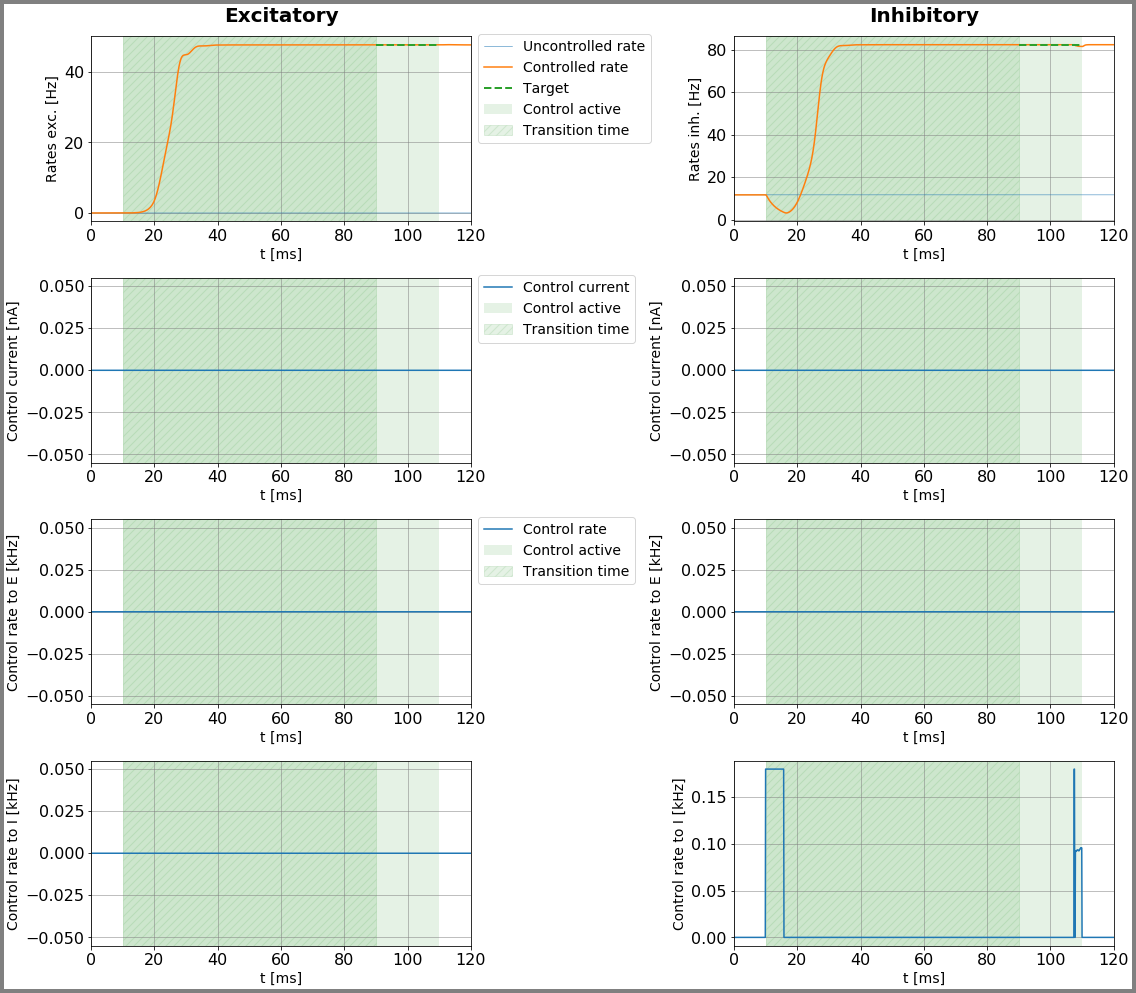

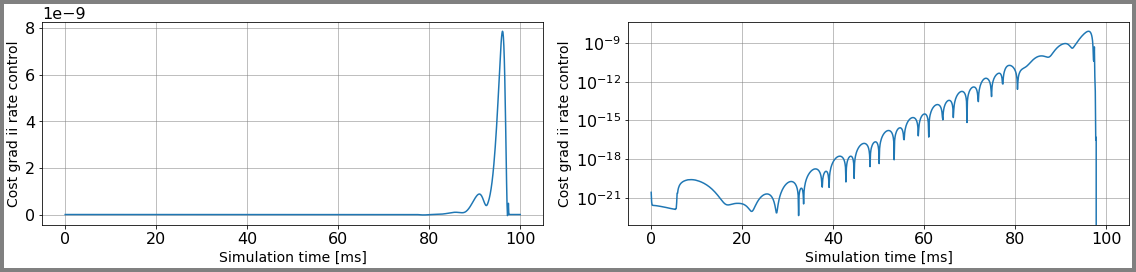

In [17]:
c_ = 6
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  56.77550773132168
Gradient descend method:  None
RUN  1 , total integrated cost =  7.126204121379057
RUN  2 , total integrated cost =  5.396151470285645
RUN  3 , total integrated cost =  5.291825899636923
RUN  4 , total integrated cost =  4.771398570355771
RUN  5 , total integrated cost =  2.9481960531437696
RUN  6 , total integrated cost =  2.9355375256452665
RUN  7 , total integrated cost =  2.6219195581289516
RUN  8 , total integrated cost =  2.423851409317696
RUN  9 , total integrated cost =  2.4235654531125426
RUN  10 , total integrated cost =  2.423140388323844
RUN  11 , total integrated cost =  2.422832945928342
RUN  12 , total integrated cost =  2.4225407182946177
RUN  13 , total integrated cost =  2.422327062562705
RUN  14 , total integrated cost =  2.4220879624119647
RUN  15 , total integrated cost =  2.42190456787101
RUN  16 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  2.333753363043083
RUN  1000 , total integrated cost =  2.333753363043083
Improved over  1000  iterations in  24.057617300000004  seconds by  95.8895068379008  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5500134775216139
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.396412196737262
Problem in initial value trasfer:  sigmai_f 0.5018203002931653 0.501820333736643
Problem in initial value trasfer:  Vmean_exc -56.17459099804681 -56.174591010815305


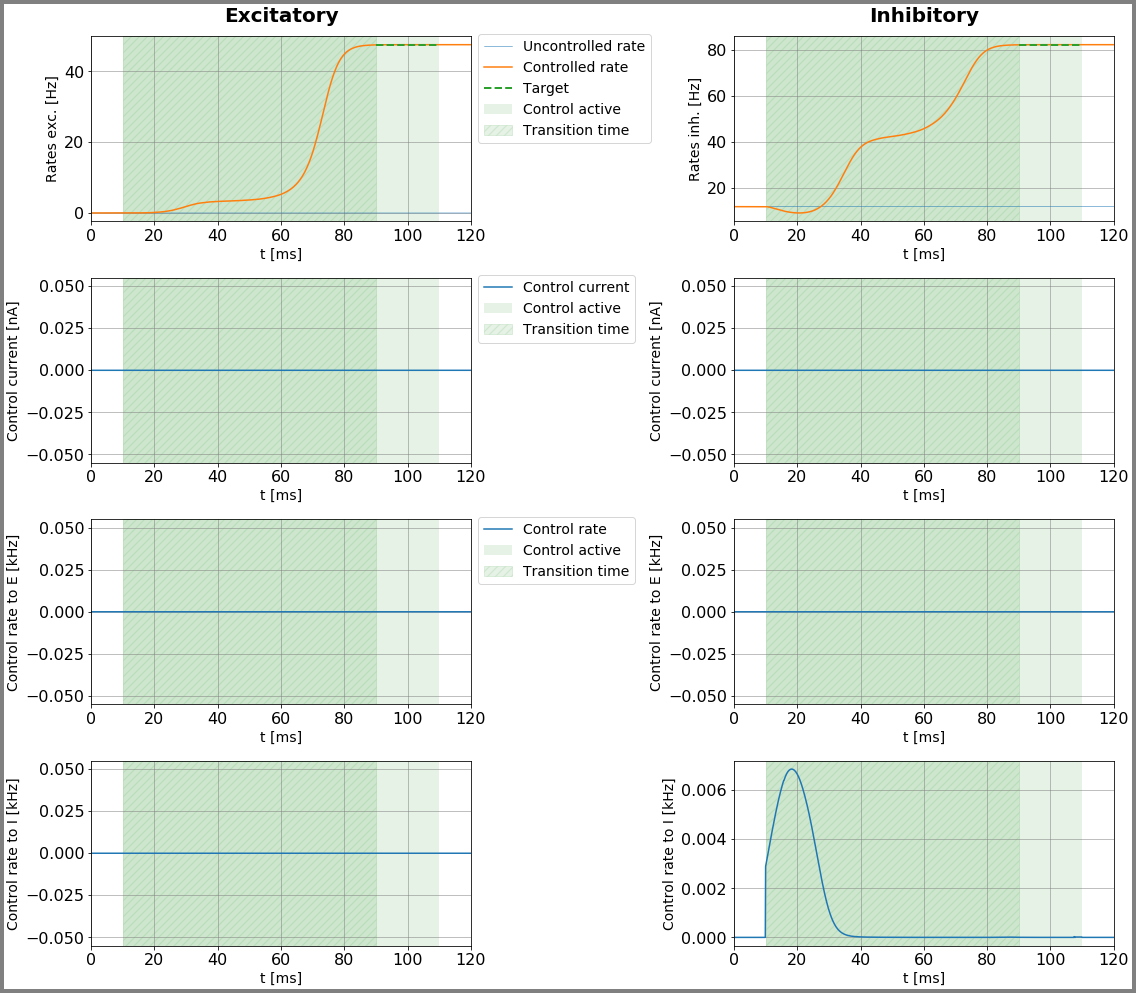

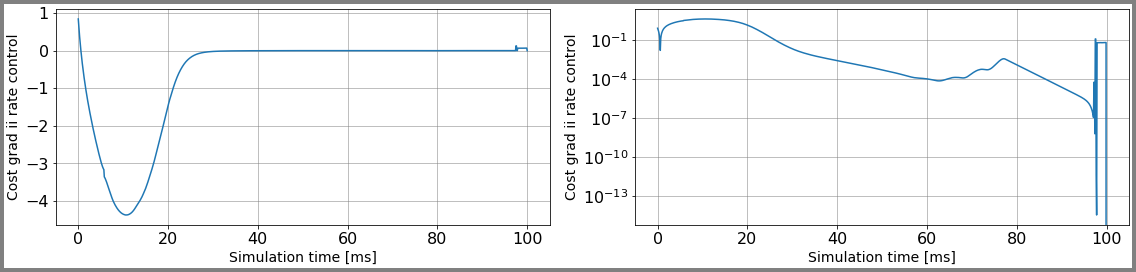

In [18]:
c_ = 6
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 8

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.557416776304856
Gradient descend method:  None
RUN  1 , total integrated cost =  0.10832467688573824
RUN  2 , total integrated cost =  0.01767992364235801
RUN  3 , total integrated cost =  0.007998900387942879
RUN  4 , total integrated cost =  0.004626859077098879
RUN  5 , total integrated cost =  0.003060183370329604
RUN  6 , total integrated cost =  0.0022264045134758473
RUN  7 , total integrated cost =  0.0017135813257835293
RUN  8 , total integrated cost =  0.0013582214042316164
RUN  9 , total integrated cost =  0.0011080985475732216
RUN  10 , total integrated cost =  0.0009278701825861029
RUN  11 , total integrated cost =  0.0007913635665927769
RUN  12 , total integrated cost =  0.0006841791711228336
RUN  13 , total integrated cost =  0.0005971248675537837
RUN  14 , total integrated cost =  0.000522892652263368
RUN  15 , total integrated 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  5.126475910650419e-10
RUN  1000 , total integrated cost =  5.126475910650419e-10
Improved over  1000  iterations in  50.334157300000015  seconds by  99.99999999321663  percent.
Problem in initial value trasfer:  sigmae_f 0.500813743477185 0.5013605063669011
Problem in initial value trasfer:  sigmai_f 0.5004276897126406 0.5006917499373765
Problem in initial value trasfer:  Vmean_exc -56.17356111034623 -56.17264207681255


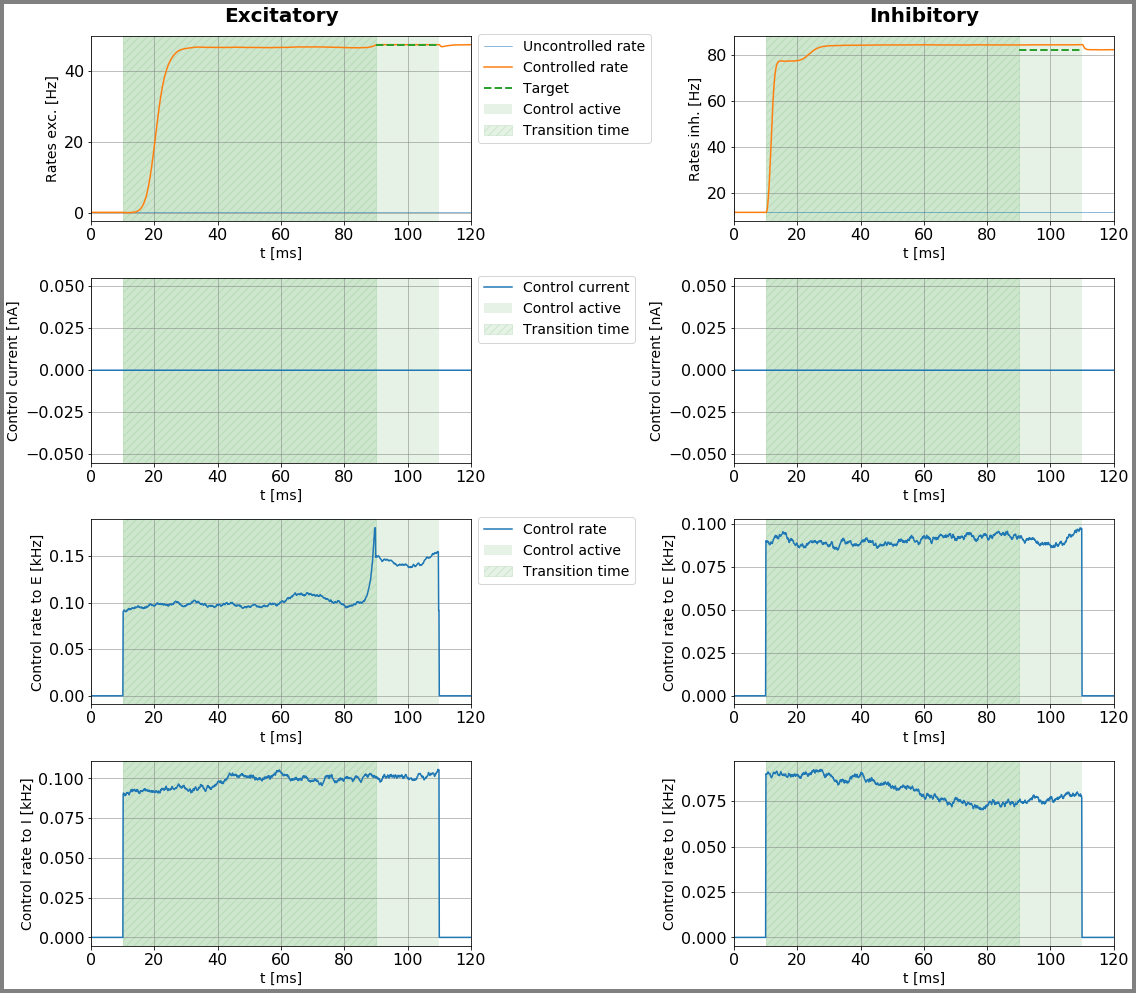

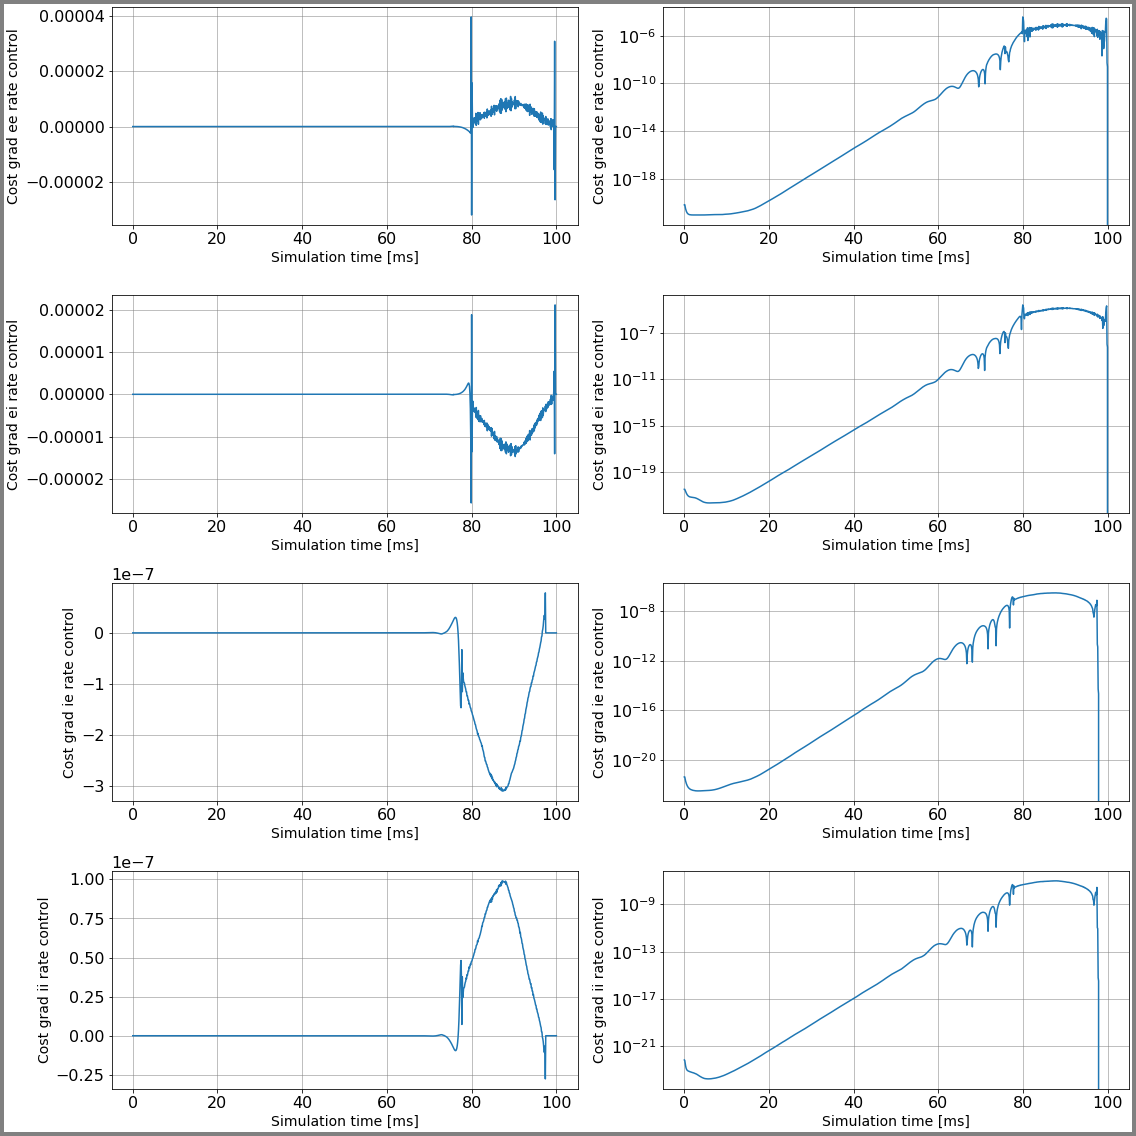

In [19]:
c_ = 7
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  565.6114689472353
Gradient descend method:  None
RUN  1 , total integrated cost =  12.404981797909294
RUN  2 , total integrated cost =  4.405003520039928
RUN  3 , total integrated cost =  1.2811956428105629
RUN  4 , total integrated cost =  1.13858979379869
RUN  5 , total integrated cost =  1.1341005416060197
RUN  6 , total integrated cost =  1.1323297592187562
RUN  7 , total integrated cost =  1.1292810934049233
RUN  8 , total integrated cost =  1.127966997555654
RUN  9 , total integrated cost =  1.125075346681643
RUN  10 , total integrated cost =  1.1238185945931862
RUN  11 , total integrated cost =  1.1209544097787103
RUN  12 , total integrated cost =  1.1196878692572276
RUN  13 , total integrated cost =  1.1168417937478512
RUN  14 , total integrated cost =  1.11560323476488
RUN  15 , total integrated cost =  1.1127960506181875
RUN  16 , tota

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.6143253347377943
RUN  1000 , total integrated cost =  0.6143253347377943
Improved over  1000  iterations in  79.00361829999997  seconds by  99.89138739780485  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7146293904768525
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.100247062759863


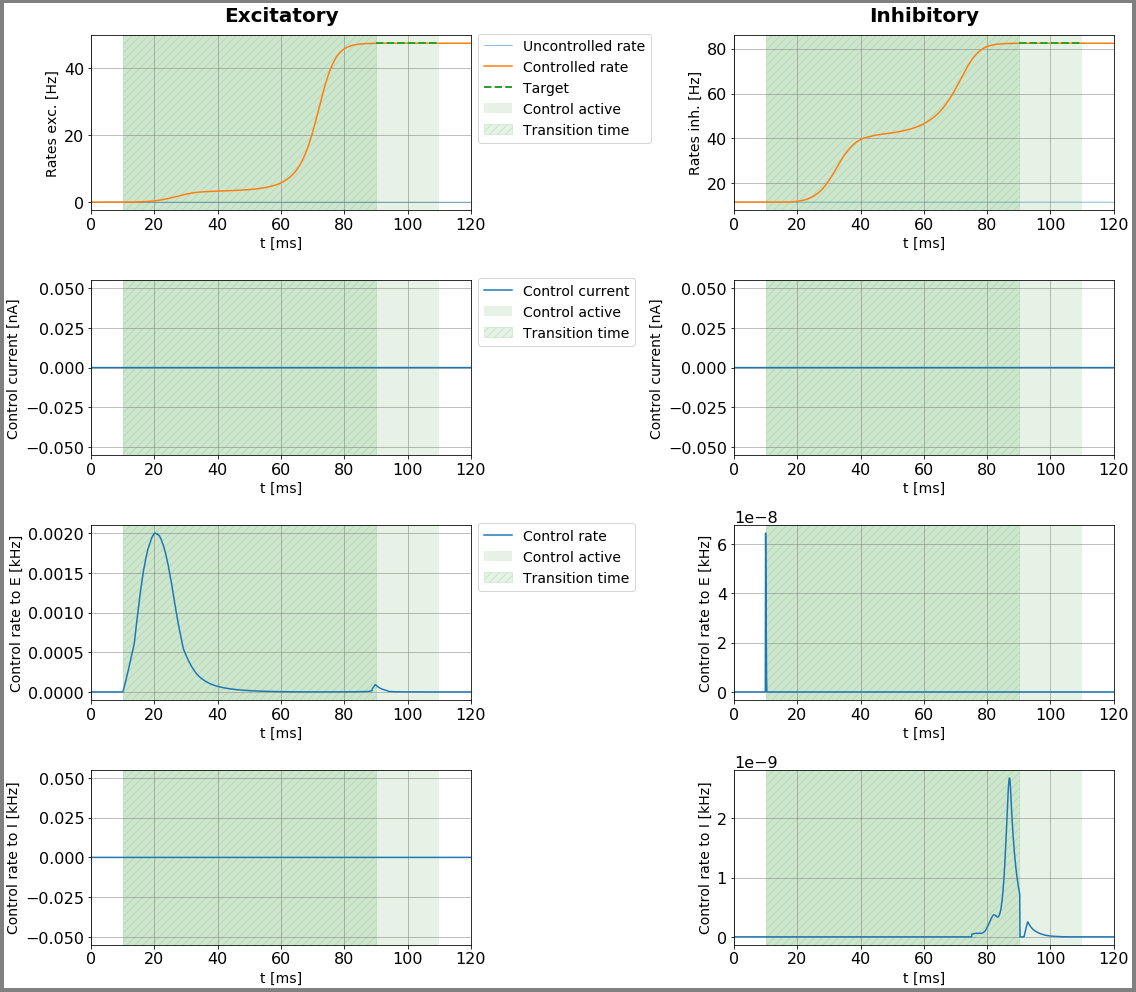

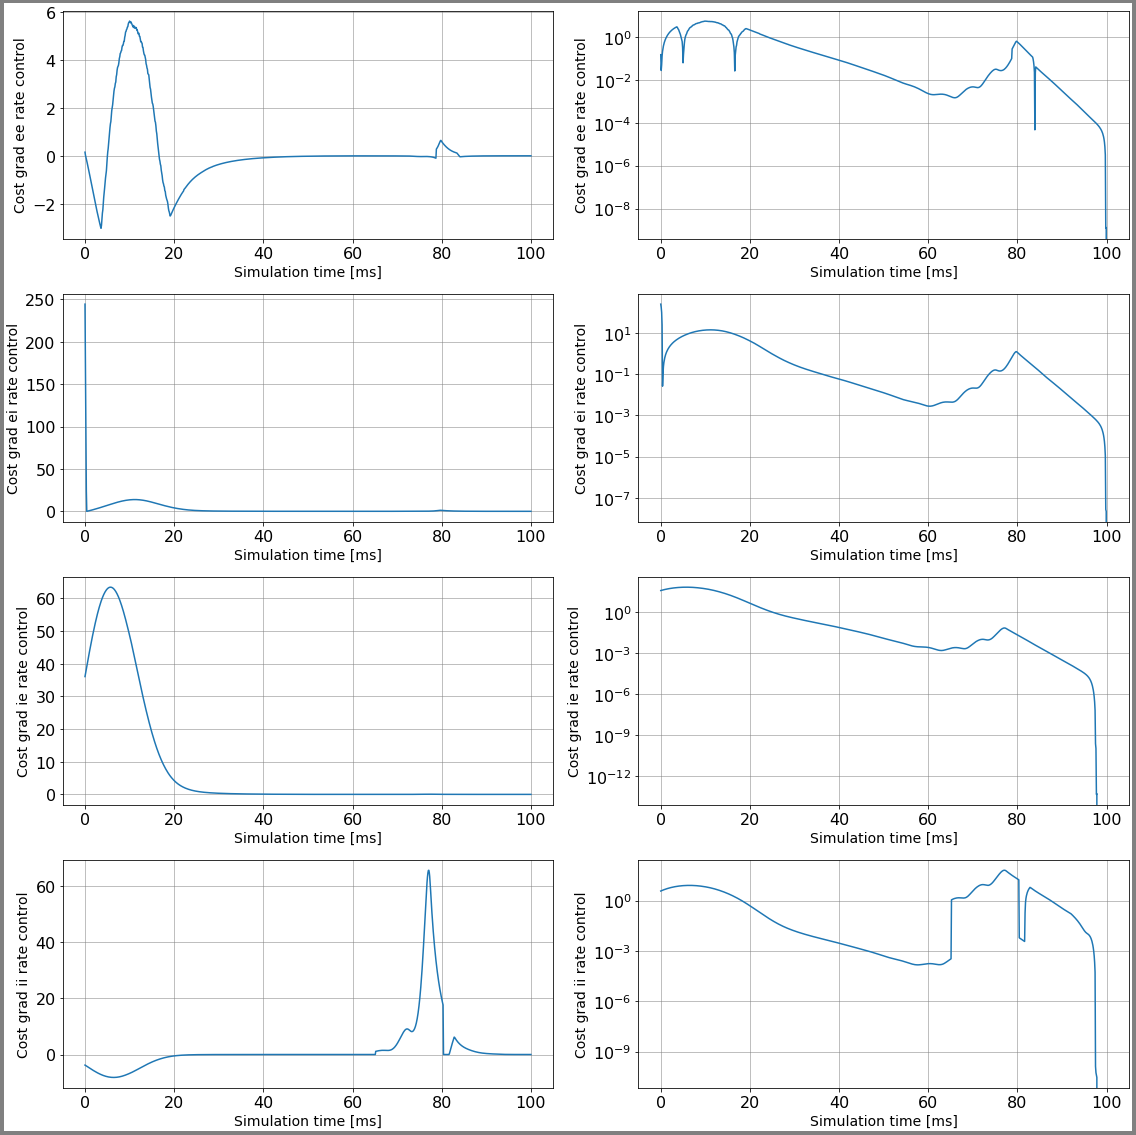

In [20]:
c_ = 7
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [21]:
print("cost a")
for i in range(len(costa)):
    j = int(len(costa[i]) - 1)
    while costa[i][j] == 0.:
        j = int(j-1)
    print(costa[i][j])

print("cost b")
for i in range(len(costb)):
    j = int(len(costb[i]) - 1)
    while costb[i][j] == 0.:
        j = int(j-1)
    print(costb[i][j])

cost a
7.879666414572664e-08
8.326046583743515e-08
0.00046238711798886074
6.868517238450723e-26
22571.787712787307
22571.787712787307
1.2185317532792055e-14
5.126475910650419e-10
cost b
102.73588233392601
49.91878128543388
50.10128848105211
0.6099459395876484
22492.291263363302
22492.176719139563
2.333753363043083
0.6143253347377943
